### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [5]:
# from langchain_openai import ChatOpenAI
# llm=ChatOpenAI(model="gpt-4o")
# llm.invoke("Hello")

In [7]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="openai/gpt-oss-20b")
llm_groq.invoke("Hey I am Krish and i like to play cricket")

AIMessage(content='Hey Krish! 👋 Great to meet you. Cricket’s an awesome sport—do you have a favorite team or player? Or maybe you’re more into the batting or bowling side? Let me know what you’re up to on the field!', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "Hey I am Krish and i like to play cricket". We should greet and ask maybe about cricket. It\'s a casual conversation. No policy issues. Just friendly.'}, response_metadata={'token_usage': {'completion_tokens': 105, 'prompt_tokens': 82, 'total_tokens': 187, 'completion_time': 0.122627022, 'completion_tokens_details': {'reasoning_tokens': 46}, 'prompt_time': 0.004310949, 'prompt_tokens_details': None, 'queue_time': 0.213000379, 'total_time': 0.126937971}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_75c733514d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a3f1-9182-72f3-9ad3-2723e4076e69-0', tool_calls

### We Will start With Creating Nodes

In [8]:
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

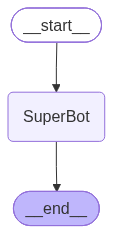

In [9]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [10]:
## Invocation

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"})

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='e54358fc-3461-4657-b9ad-6bf8f46d1d23'),
  AIMessage(content='Hi Krish! That’s great to hear—you’re a cricket fan? Which teams or players do you follow most? If you want to chat about recent matches, upcoming tournaments, or even dive into some stats, just let me know!', additional_kwargs={'reasoning_content': 'User says: "Hi,My name is Krish And I like cricket". They didn\'t ask a question. We need to respond friendly, maybe ask more about cricket. The user says they like cricket. We can respond acknowledging. No policy issues. Just chat.'}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 82, 'total_tokens': 193, 'completion_time': 0.114067956, 'completion_tokens_details': {'reasoning_tokens': 54}, 'prompt_time': 0.004577166, 'prompt_tokens_details': None, 'queue_time': 0.309738911, 'total_time': 0.118645122}, 'model_name': 'openai/g

#### Streaming The responses

In [14]:
for event in graph_builder.stream({"messages":"Hello My name is Rishabh"},stream_mode ="values"):
    print(event)

{'messages': [HumanMessage(content='Hello My name is Rishabh', additional_kwargs={}, response_metadata={}, id='79e14176-53de-46ab-84c0-17055cd3b4a0')]}
{'messages': [HumanMessage(content='Hello My name is Rishabh', additional_kwargs={}, response_metadata={}, id='79e14176-53de-46ab-84c0-17055cd3b4a0'), AIMessage(content='Hello Rishabh! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hello My name is Rishabh". We should respond politely. No special instructions.'}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 78, 'total_tokens': 123, 'completion_time': 0.050268535, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.00373454, 'prompt_tokens_details': None, 'queue_time': 0.211868378, 'total_time': 0.054003075}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e23fc997ca', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a4